In [118]:
# Imports and Spark session
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import BooleanType
import os, json, math
import pandas as pd
import numpy as np

spark = SparkSession.builder.appName("Nutrient Similarity Search").getOrCreate()
print("Spark version:", spark.version)

Spark version: 4.0.1


In [119]:
# Configuration
input_path = "output/nutritional_profiles"
fallback_file = "output/nutritional_profiles/part-00000-c8bad44e-47d3-4d65-81e1-c1a23350546a-c000.snappy.parquet"
output_dir = "output/SimilaritySearch"

# Select the reference item by name or ID
query_by_name = "chicken"   # substring in name/description (case-insensitive). Set None to use ID
query_by_id = None           # alternative: an exact fdc_id/id 2677354

# Global result and constraints
top_k = 20
same_category_only = True        # restrict to the same category (when category exists)
use_per_kcal = True              # use per-kcal densities
scaling = "zscore"              # "none" or "zscore"
show_chart = True
top_n_chart = 10

# Text filters
exclude_allergens = []           # e.g., ['gluten','peanut','milk']
dislikes = []                    # e.g., ['pork','alcohol']

# Per-nutrient config: toggle use, set weights, and set relative constraints to the query item
# constraint: None | 'less' | 'more' (compared to the query's value)
feature_config = {
    # Macros
    'protein':  { 'use': True,  'weight': 1.0, 'constraint': None },
    'carb':     { 'use': True,  'weight': 1.0, 'constraint': None },
    'fat':      { 'use': True,  'weight': 1.0, 'constraint': None },
    # Carbs detail
    'fiber':    { 'use': True,  'weight': 0.8, 'constraint': None },
    'sugar':    { 'use': True,  'weight': 0.8, 'constraint': None },
    # Sodium
    'sodium':   { 'use': True,  'weight': 0.5, 'constraint': 'less' },
    # Example micronutrients (if available in the nutritional profile)
    'calcium':  { 'use': False, 'weight': 0.4, 'constraint': None },
    'iron':     { 'use': False, 'weight': 0.4, 'constraint': None },
    'potassium':{ 'use': False, 'weight': 0.4, 'constraint': None },
    'magnesium':{ 'use': False, 'weight': 0.4, 'constraint': None },
    'zinc':     { 'use': False, 'weight': 0.4, 'constraint': None },
}

# Auto-detect extra nutrient columns in the dataset (vitamins/minerals) and add to config with use=False
auto_detect_extra_nutrients = True


In [120]:
# Read dataset
path = input_path if os.path.exists(input_path) else fallback_file
print('Input path:', path)
df = spark.read.parquet(path)
df.printSchema()

Input path: output/nutritional_profiles
root
 |-- fdc_id: long (nullable = true)
 |-- food_description: string (nullable = true)
 |-- food_type: string (nullable = true)
 |-- total_nutrients: long (nullable = true)
 |-- energy: double (nullable = true)
 |-- protein: double (nullable = true)
 |-- carbs: double (nullable = true)
 |-- total_fat: double (nullable = true)
 |-- water: double (nullable = true)
 |-- ash: double (nullable = true)
 |-- alcohol: double (nullable = true)
 |-- caffeine: double (nullable = true)
 |-- fiber: double (nullable = true)
 |-- sugars: double (nullable = true)
 |-- glucose: double (nullable = true)
 |-- fructose: double (nullable = true)
 |-- sucrose: double (nullable = true)
 |-- lactose: double (nullable = true)
 |-- saturated_fat: double (nullable = true)
 |-- monounsaturated_fat: double (nullable = true)
 |-- polyunsaturated_fat: double (nullable = true)
 |-- trans_fat: double (nullable = true)
 |-- cholesterol: double (nullable = true)
 |-- vitamin_a: 

In [121]:
# Detect columns
def detect_column(df, candidates):
    for cand in candidates:
        for i, col in enumerate(df.columns):
            if col.lower() == cand.lower():
                return df.columns[i]
    for cand in candidates:
        for i, col in enumerate(df.columns):
            if cand.lower() in col.lower():
                return df.columns[i]
    return None

id_col = detect_column(df, ['fdc_id', 'id'])
name_col = detect_column(df, ['description', 'food_name', 'name', 'brand_name'])
kcal_col = detect_column(df, ['energy_kcal', 'energy', 'kcal', 'calories', '1008'])
protein_col = detect_column(df, ['protein_g', 'protein', '1003'])
carb_col = detect_column(df, ['carbohydrate_g', 'carbohydrates', 'carb', 'carbohydrate', '1005'])
fat_col = detect_column(df, ['fat_g', 'fat', 'total_lipid', '1004'])
fiber_col = detect_column(df, ['fiber_g', 'dietary_fiber', 'fiber', '1079'])
sugar_col = detect_column(df, ['sugar_g', 'sugar', '2000'])
sodium_col = detect_column(df, ['sodium_mg', 'sodium', '1093'])
category_col = detect_column(df, ['food_category', 'wweia_food_category', 'category'])
text_col = detect_column(df, ['ingredients', 'ingredients_text', 'description', 'food_name', 'name', 'brand_name'])

# Possible micronutrients
calcium_col   = detect_column(df, ['calcium_mg', 'calcium'])
iron_col      = detect_column(df, ['iron_mg', 'iron'])
potassium_col = detect_column(df, ['potassium_mg', 'potassium'])
magnesium_col = detect_column(df, ['magnesium_mg', 'magnesium'])
zinc_col      = detect_column(df, ['zinc_mg', 'zinc'])

print('Cols:', id_col, name_col, kcal_col)
if not (id_col and name_col and kcal_col):
    raise RuntimeError('Missing essential columns (id/name/kcal).')

# Update feature_config with detected columns
base_feature_cols = {
    'protein': protein_col,
    'carb': carb_col,
    'fat': fat_col,
    'fiber': fiber_col,
    'sugar': sugar_col,
    'sodium': sodium_col,
    'calcium': calcium_col,
    'iron': iron_col,
    'potassium': potassium_col,
    'magnesium': magnesium_col,
    'zinc': zinc_col,
}

for fname, cfg in feature_config.items():
    col_found = base_feature_cols.get(fname)
    feature_config[fname]['column'] = col_found  # may be None if not present in dataset

# Auto-detect extra nutrient columns (vitamins/minerals) not already covered
if auto_detect_extra_nutrients:
    known_cols = set([c for c in base_feature_cols.values() if c])
    candidates = []
    keywords = ['vitamin', 'vit_', 'vitamina', 'calcium', 'iron', 'potassium', 'magnesium', 'zinc', 'phosphorus', 'cholesterol']
    for c in df.columns:
        cl = c.lower()
        if c in known_cols:
            continue
        if any(k in cl for k in keywords):
            # add to config if not present
            key = cl.replace(' ', '_')
            if key not in feature_config:
                feature_config[key] = { 'use': False, 'weight': 0.3, 'constraint': None, 'column': c }

print('Feature config (detected columns attached):')
for k,v in feature_config.items():
    print(' ', k, '->', v.get('column'))


Cols: fdc_id food_description energy
Feature config (detected columns attached):
  protein -> protein
  carb -> carbs
  fat -> total_fat
  fiber -> fiber
  sugar -> sugars
  sodium -> sodium
  calcium -> calcium
  iron -> iron
  potassium -> potassium
  magnesium -> magnesium
  zinc -> zinc
  cholesterol -> cholesterol
  vitamin_a -> vitamin_a
  vitamin_c -> vitamin_c
  vitamin_d -> vitamin_d
  vitamin_e -> vitamin_e
  vitamin_k -> vitamin_k
  vitamin_b6 -> vitamin_b6
  vitamin_b12 -> vitamin_b12
  phosphorus -> phosphorus


In [122]:
# Build base dataframe with densities
df_base = df.filter(F.col(kcal_col) > 0)

def safe_div(num_col, den_col):
    return (F.col(num_col) / F.when(F.col(den_col) > 0, F.col(den_col)).otherwise(F.lit(1)))

# Compute per-unit versions for all configured features when possible
if use_per_kcal:
    df_work = df_base
else:
    df_work = df_base

# Map of feature -> selected output column name used downstream
selected_feature_cols = {}

for fname, cfg in feature_config.items():
    src = cfg.get('column')
    if not src:
        # if missing, fill with zero later
        continue
    if use_per_kcal:
        out_col = f"{fname}_per_kcal"
        df_work = df_work.withColumn(out_col, safe_div(src, kcal_col))
    else:
        out_col = f"{fname}_per_100g"
        df_work = df_work.withColumn(out_col, F.col(src))
    selected_feature_cols[fname] = out_col

# Base selection
sel = [id_col, name_col]
if category_col:
    sel.append(category_col)

# Features to use in similarity
feature_keys_used = [k for k, v in feature_config.items() if v.get('use', False)]
feat_cols = [selected_feature_cols.get(k, None) for k in feature_keys_used]
# For missing columns, add a literal 0.0 to keep vector shape consistent
for i, (k, colname) in enumerate(list(zip(feature_keys_used, feat_cols))):
    if colname is None:
        fill_col = f"__missing_{k}"
        df_work = df_work.withColumn(fill_col, F.lit(0.0))
        feat_cols[i] = fill_col

sel.extend([c for c in feat_cols if c])
if text_col and text_col != name_col:
    sel.append(text_col)

pdf = df_work.select(*sel).toPandas()
pdf = pdf.rename(columns={id_col: 'ID', name_col: 'Food'})
if category_col:
    pdf = pdf.rename(columns={category_col: 'Category'})
if text_col and text_col != name_col:
    pdf = pdf.rename(columns={text_col: 'Text'})

# Drop any duplicate columns
try:
    pdf = pdf.loc[:, ~pd.Index(pdf.columns).duplicated()]
except Exception as e:
    print('Duplicate column drop skipped:', e)

print('Rows:', len(pdf))

# Replace NaN with 0 for features
for c in feat_cols:
    pdf[c] = pdf[c].fillna(0.0)

# Build feature matrix and scaling (with weights)
X = pdf[feat_cols].to_numpy(dtype=float)
weights_vec = np.array([feature_config[k].get('weight', 1.0) for k in feature_keys_used], dtype=float)
# Apply scaling
if scaling == 'zscore':
    means = np.nanmean(X, axis=0)
    stds = np.nanstd(X, axis=0)
    stds = np.where(stds <= 1e-12, 1.0, stds)
    X = (X - means) / stds
else:
    means = np.zeros(X.shape[1]); stds = np.ones(X.shape[1])
# Apply weights
X = X * weights_vec
row_norms = np.linalg.norm(X, axis=1) + 1e-12


Rows: 4258


In [123]:
# Resolve reference item

def get_food_series(pdf):
    val = pdf['Food']
    if isinstance(val, pd.DataFrame):
        return val.iloc[:, 0]
    return val

def find_query_index(pdf, name_substr, id_val):
    if id_val is not None:
        mask = (pdf['ID'].astype(str) == str(id_val))
        idxs = np.where(mask.values)[0]
        if len(idxs):
            return idxs[0]
    if name_substr is not None:
        s = str(name_substr).lower()
        food_series = get_food_series(pdf)
        mask = food_series.astype(str).str.lower().str.contains(s)
        idxs = np.where(mask.values)[0]
        if len(idxs):
            return idxs[0]
    return None

q_idx = find_query_index(pdf, query_by_name, query_by_id)
if q_idx is None:
    raise ValueError('Reference item not found. Adjust query_by_name or query_by_id.')
q_vec = X[q_idx:q_idx+1, :]  # 1xD
q_norm = float(np.linalg.norm(q_vec) + 1e-12)
q_name = str(get_food_series(pdf).iloc[q_idx])
q_cat = pdf.loc[q_idx, 'Category'] if 'Category' in pdf.columns else None
print('Query:', q_name, '| Category:', q_cat)

Query: CHICKEN STIR FRY, CHICKEN | Category: None


In [124]:
# Confirm reference item based on already computed variables
try:
    _ = q_idx
    _ = q_vec
    _ = q_norm
except NameError:
    raise RuntimeError('Variables q_idx/q_vec/q_norm are not set. Run the reference resolution cell.')

# Get name as a scalar even if duplicate columns exist
food_col = pdf['Food']
if isinstance(food_col, pd.DataFrame):
    q_name = str(food_col.iloc[q_idx, 0])
else:
    q_name = str(food_col.iloc[q_idx])
q_cat = pdf.loc[q_idx, 'Category'] if 'Category' in pdf.columns else None
print('Query:', q_name, '| Category:', q_cat)

Query: CHICKEN STIR FRY, CHICKEN | Category: None


In [125]:
# Cosine similarity and filtering
sims = (X @ q_vec.T).reshape(-1) / (row_norms * q_norm)
# Exclude the query item itself
sims[q_idx] = -1.0

res_df = pdf.copy()
res_df['Similarity'] = sims

# Map feature columns used for constraints (depending on use_per_kcal)
feat_col_map = {k: selected_feature_cols.get(k) for k in feature_keys_used}

# Query reference values for features
q_vals = {}
for k, col in feat_col_map.items():
    try:
        q_vals[k] = float(res_df.loc[q_idx, col]) if col in res_df.columns else 0.0
    except Exception:
        q_vals[k] = 0.0

mask = res_df['Similarity'] > -1.0

# Per-nutrient constraints according to feature_config
for k in feature_keys_used:
    constraint = feature_config[k].get('constraint')
    col = feat_col_map.get(k)
    if not constraint or not col or col not in res_df.columns:
        continue
    if constraint == 'less':
        mask &= (res_df[col] <= q_vals[k])
    elif constraint == 'more':
        mask &= (res_df[col] >= q_vals[k])

# Category restriction
if same_category_only and ('Category' in res_df.columns) and pd.notna(pdf.loc[q_idx, 'Category'] if 'Category' in pdf.columns else None):
    q_cat = pdf.loc[q_idx, 'Category']
    mask &= (res_df['Category'].astype(str) == str(q_cat))

# Text filters (allergens, dislikes)
if 'Text' in res_df.columns:
    txt = res_df['Text'].astype(str).str.lower()
    if exclude_allergens:
        for k in exclude_allergens:
            kk = str(k).lower()
            mask &= ~txt.str.contains(kk)
    if dislikes:
        for k in dislikes:
            kk = str(k).lower()
            mask &= ~txt.str.contains(kk)

cand = res_df[mask].sort_values('Similarity', ascending=False).head(top_k).copy()

# Percentage differences vs query for selected features
for k in feature_keys_used:
    col = feat_col_map.get(k)
    if col and col in cand.columns:
        qv = q_vals.get(k, 0.0)
        cand[f'Delta {k} (%)'] = ((cand[col] - qv) / (qv + 1e-12)) * 100.0

# Result columns
result_cols = ['ID','Food']
if 'Category' in cand.columns: result_cols.append('Category')
result_cols += ['Similarity']
# include feature values for transparency
for k in feature_keys_used:
    col = feat_col_map.get(k)
    if col and col in cand.columns:
        result_cols.append(col)
# include deltas if present
for k in feature_keys_used:
    dname = f'Delta {k} (%)'
    if dname in cand.columns:
        result_cols.append(dname)

cand = cand[result_cols]
print('Found candidates:', len(cand))

Found candidates: 20


ID,Food,Similarity,protein_per_kcal,carb_per_kcal,fat_per_kcal,fiber_per_kcal,sugar_per_kcal,sodium_per_kcal,Delta protein (%),Delta carb (%),Delta fat (%),Delta fiber (%),Delta sugar (%),Delta sodium (%)
1142933,"GLUTEN FREE VEGETABLE PASTA, ROTINI WITH GREEN LENTILS, KALE, SPINACH AND CAULIFLOWER",0.992,0.059945,0.179808,0.002500,0.009890,0.010000,0.074176,4.903846,11.057692,-73.750000,3.846154,-30.000000,-91.346154
2217571,"SQUID INK SPAGHETTI, ARTISAN EGG PASTA, SQUID INK",0.919,0.041667,0.183333,0.012500,0.008333,0.008333,0.734375,-27.083333,13.235294,31.250000,-12.500000,-41.666667,-14.322917
1682120,"MEDITERRANEAN QUINOA BLEND OF QUINOA, BROWN RICE, ITALIAN STYLE GREEN BEANS, ZUCCHINI, YELLOW SQUASH & RED PEPPERS, MEDITERRANEAN",0.898,0.075152,0.150303,0.000000,0.025758,0.012576,0.060606,31.515152,-7.165775,-100.000000,170.454545,-11.969697,-92.929293
1171238,"ARTISAN BISTRO, WILD SALMON",0.898,0.064040,0.138687,0.021313,0.014141,0.024848,0.484848,12.070707,-14.340463,123.787879,48.484848,73.939394,-43.434343
602326,"KLUSKI ENRICHED DURUM FLOUR EGG NOODLES, KLUSKI",0.895,0.040891,0.177201,0.015903,0.004580,0.004555,0.045802,-28.441476,9.447687,66.984733,-51.908397,-68.117048,-94.656489
2096900,ALL RAW VEGAN VERY BERRY MUESLI,0.893,0.044100,0.180600,0.013200,0.018000,0.026400,0.000000,-22.825000,11.547059,38.600000,89.000000,84.800000,-100.000000
2680057,PREMIUM ENRICHED NOODLE STYLE PASTA,0.880,0.039973,0.204808,0.005000,0.009890,0.010000,0.049451,-30.048077,26.498869,-47.500000,3.846154,-30.000000,-94.230769
394577,"SPAGHETTI, ENRICHED PASTA WITH VEGGIES",0.879,0.040028,0.205070,0.005014,0.010084,0.010000,0.000000,-29.950980,26.660900,-47.352941,5.882353,-30.000000,-100.000000
2594511,YOLK FREE HOMESTYLE RIBBONS PASTA,0.879,0.040028,0.205070,0.005014,0.010084,0.010000,0.050420,-29.950980,26.660900,-47.352941,5.882353,-30.000000,-94.117647
2009532,"TRICOLOR ROTINI, TRICOLOR",0.879,0.040028,0.205070,0.005014,0.010084,0.010000,0.151261,-29.950980,26.660900,-47.352941,5.882353,-30.000000,-82.352941


/tmp/ipykernel_4462/3096991157.py:37: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


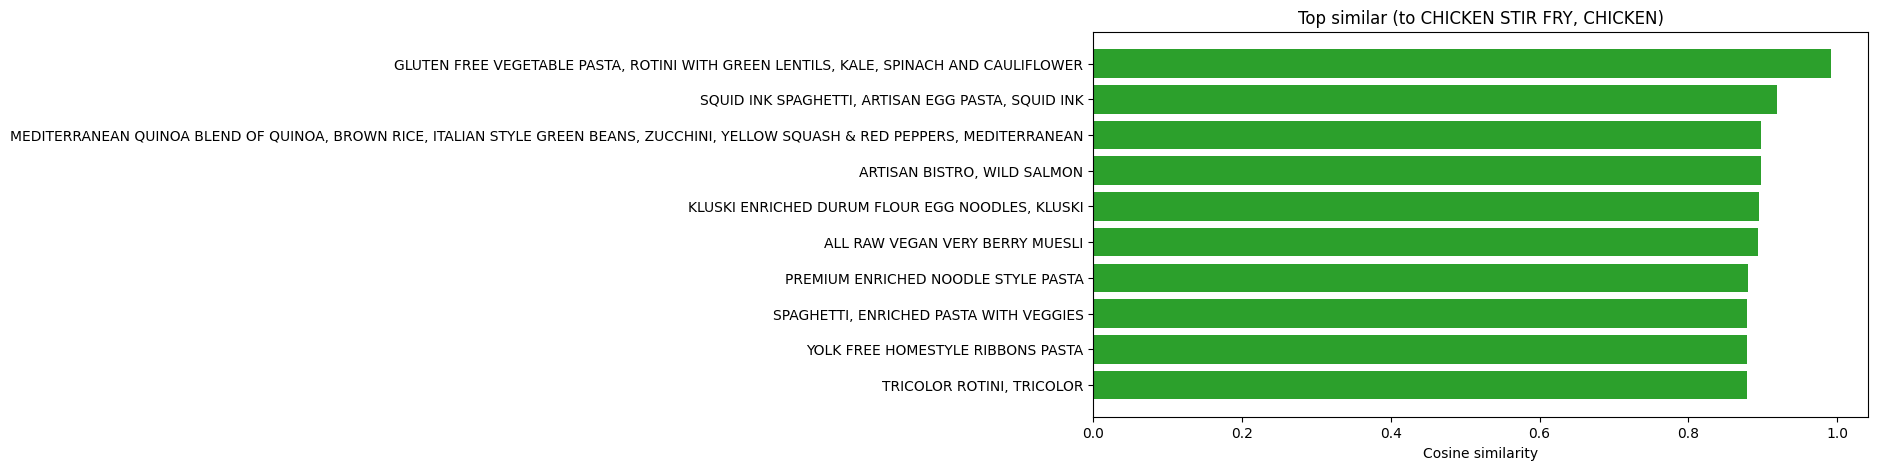

In [126]:
# Visualization
from IPython.display import display

# Ensure unique columns and clean index for Styler
cand_view = cand.copy()
cand_view = cand_view.loc[:, ~cand_view.columns.duplicated()]
cand_view = cand_view.reset_index(drop=True)
if 'Food' in cand_view.columns:
    cand_view['Food'] = cand_view['Food'].astype(str)

styler = cand_view.style.format({
    'Similarity': '{:.3f}',
    'Delta Protein (%)': '{:.1f}',
    'Delta Sodium (%)': '{:.1f}'
}).set_caption('Nutritional similarity to: ' + str(q_name))
try:
    if hasattr(styler, 'hide_index'):
        styler = styler.hide_index()
    elif hasattr(styler, 'hide'):
        styler = styler.hide(axis='index')
except Exception as e:
    print('Index hide skipped:', e)
styler = styler.background_gradient(cmap='Greens', subset=['Similarity'])
display(styler)

# Chart: Top-N Similarity
try:
    if show_chart and len(cand_view) > 0:
        import matplotlib.pyplot as plt
        topn = cand_view.head(top_n_chart)
        labels = topn['Food'].astype(str).tolist() if 'Food' in topn.columns else [str(i) for i in range(len(topn))]
        values = topn['Similarity'].tolist()
        plt.figure(figsize=(10,5))
        plt.barh(list(reversed(labels)), list(reversed(values)), color='#2ca02c')
        plt.xlabel('Cosine similarity')
        plt.title('Top similar (to ' + str(q_name) + ')')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print('Chart skipped:', e)

In [127]:
# Save output
os.makedirs(output_dir, exist_ok=True)
slug = str(q_name).lower().replace(' ', '_') if 'q_name' in globals() else 'query'
out_base = os.path.join(output_dir, slug)
os.makedirs(out_base, exist_ok=True)
csv_path = os.path.join(out_base, 'similar_results.csv')
json_path = os.path.join(out_base, 'similar_results.json')
cand.to_csv(csv_path, index=False)
cand.to_json(json_path, orient='records', lines=False)
meta = {
  'query': { 'id': str(pdf.loc[q_idx, 'ID']), 'name': str(q_name), 'category': str(q_cat) },
  'config': {
      'top_k': top_k,
      'same_category_only': same_category_only,
      'use_per_kcal': use_per_kcal,
      'scaling': scaling,
      'features_used': feature_keys_used,
      'feature_config': feature_config,
      'exclude_allergens': exclude_allergens,
      'dislikes': dislikes
  }
}
with open(os.path.join(out_base, 'meta.json'), 'w') as f:
    json.dump(meta, f, indent=2)
print('Saved:', csv_path, 'and', json_path)

Saved: output/SimilaritySearch/chicken_stir_fry,_chicken/similar_results.csv and output/SimilaritySearch/chicken_stir_fry,_chicken/similar_results.json


## Usage
1. Run cells 1–4 (imports, config, read, column detection).
2. In the Config cell, set `query_by_name` or `query_by_id`, `top_k`, text filters, and the `feature_config` toggles/weights/constraints.
3. Run the compute cells (densities, matrix, query resolution, similarities).
4. View the table and chart, then save results (last cell).
5. Files are saved in `output/SimilaritySearch/<slug>/`.